   Employee ID  Age  Gender  Years at Company    Job Role  Monthly Income  \
0         8410   31    Male                19   Education            5390   
1        64756   59  Female                 4       Media            5534   
2        30257   24  Female                10  Healthcare            8159   
3        65791   36  Female                 7   Education            3989   
4        65026   56    Male                41   Education            4821   

  Work-Life Balance Job Satisfaction Performance Rating  Number of Promotions  \
0         Excellent           Medium            Average                     2   
1              Poor             High                Low                     3   
2              Good             High                Low                     0   
3              Good             High               High                     1   
4              Fair        Very High            Average                     0   

   ... Number of Dependents  Job Level Company Siz

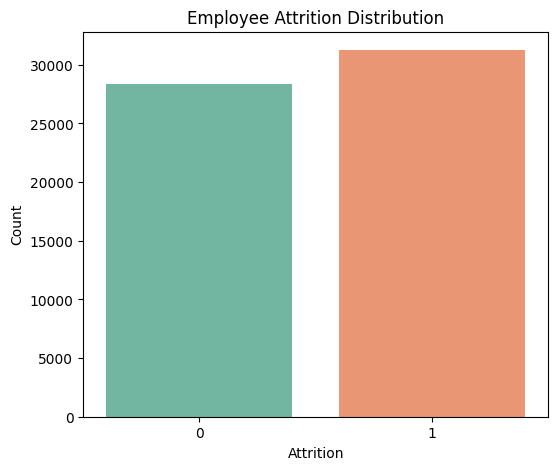

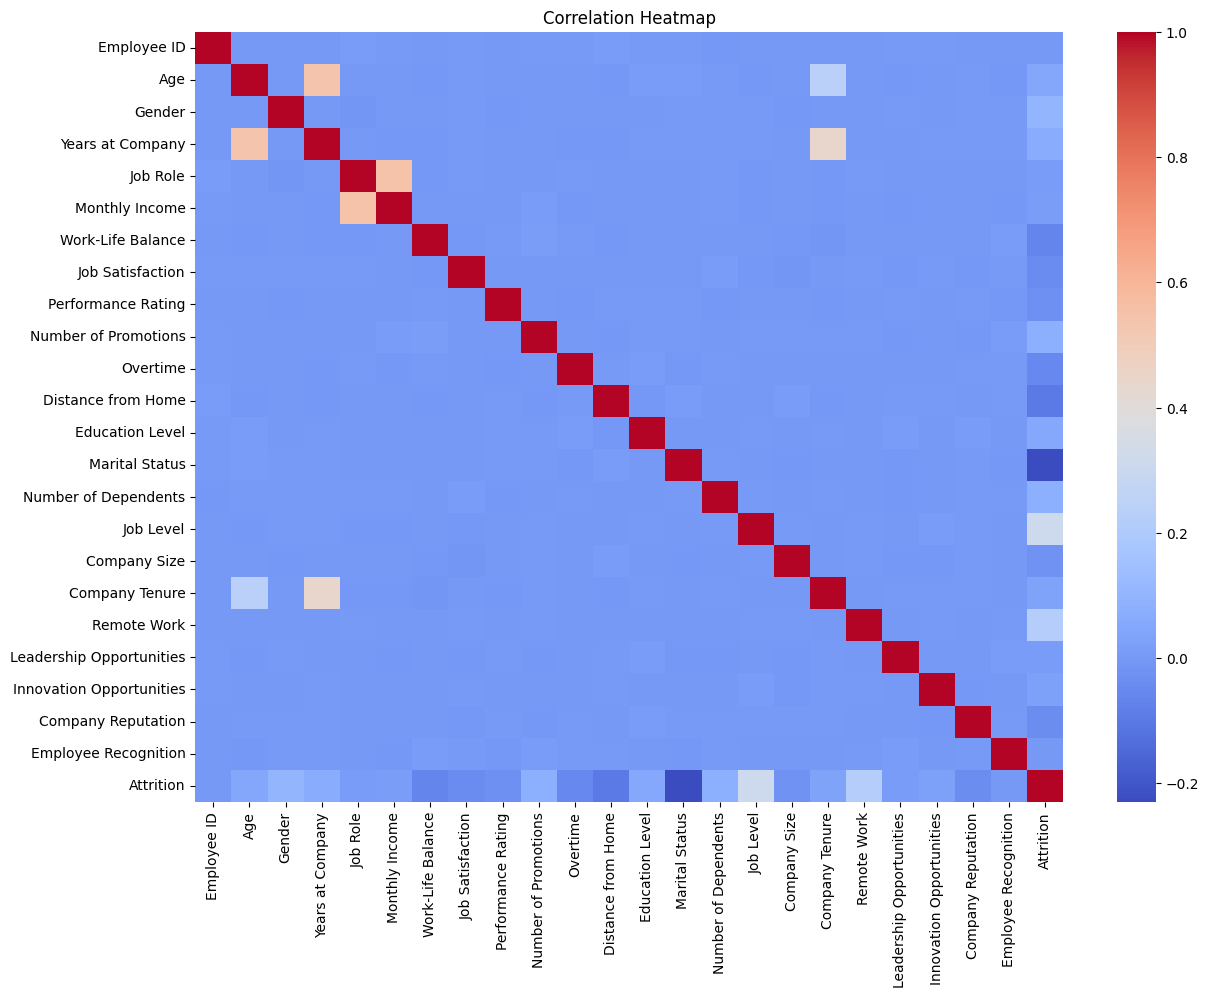

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler

#load dataset
df = pd.read_csv("C:/Users/user/Downloads/train.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

#numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
df.columns = df.columns.str.strip()
label = LabelEncoder()

df["Attrition"] = label.fit_transform(df["Attrition"])
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = LabelEncoder().fit_transform(df[col])

#feature and target
X = df.drop(["Attrition","Employee ID"], axis=1)

y = df["Attrition"]

#Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#logistic regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

#decision tree
dt = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)
#metrics of ML
def evaluate_model(name,y_true,pred):

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :",accuracy_score(y_true,pred))
    print("Precision:",precision_score(y_true,pred))
    print("Recall   :",recall_score(y_true,pred))
    print("F1 Score :",f1_score(y_true,pred))

    print("\nClassification Report\n")

    print(classification_report(y_true,pred))

#model evaluation
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)
evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

#model comparison
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred)
    ],

    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,dt_pred)
    ],

    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,dt_pred)
    ],

    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,dt_pred)
    ]

})

print(comparison)

#counter plot
plt.figure(figsize=(6,5))

sns.countplot(
    x='Attrition',
    hue='Attrition',
    data=df,
    palette='Set2',
    legend=False
)

plt.title("Employee Attrition Distribution")

plt.xlabel("Attrition")

plt.ylabel("Count")

plt.show()

#heat map
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()